In [9]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torchvision.datasets as datasets
import torchvision.transforms as transforms 
from torch.utils.data import random_split, DataLoader
import multiprocessing
import matplotlib.pyplot as plt
import pandas as pd

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print('torch:', torch.__version__)

device: cpu
torch: 2.10.0+cpu


In [10]:
transformer = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(0.5,0.5)
])

train_full = datasets.EMNIST(root="./data", train=True, download=True, transform=transformer, split="balanced")
test_ds = datasets.EMNIST(root="./data", train=False, download=True, transform=transformer, split="balanced")

class_names = train_full.classes
print("classes:", len(class_names))
print("train size:", len(train_full))
print("test size:", len(test_ds))

100%|██████████| 562M/562M [00:25<00:00, 22.2MB/s] 


classes: 47
train size: 112800
test size: 18800


In [11]:
BATCH_SIZE = 64

val_ratio = 0.2
val_size = int(len(train_full) * val_ratio)
train_size = len(train_full) - val_size

gen = torch.Generator().manual_seed(42)

train_ds, val_ds = random_split(train_full,[train_size,val_size],generator=gen)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,shuffle=False,num_workers=2)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE,shuffle=False,num_workers=2)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE,shuffle=False,num_workers=2)

X_batch,y_batch = next(iter(train_loader))
print(X_batch.shape,y_batch.shape)

torch.Size([64, 1, 28, 28]) torch.Size([64])


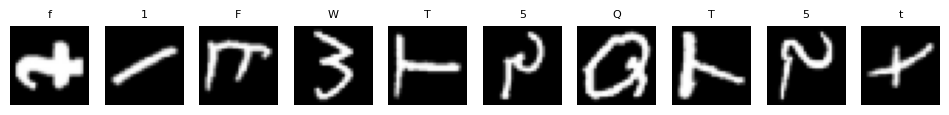

In [19]:
def show_images(loader, n: int = 10):
    x, y = next(iter(loader))
    x = x[:n]
    y = y[:n]

    plt.figure(figsize=(12, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = x[i].squeeze().numpy()
        img = img * 0.5 + 0.5
        plt.imshow(img, cmap="gray")
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()
    
def plot_history(history: dict, title: str = "",save = False):
    epochs = np.arange(1, len(history["train_loss"]) + 1)
    fig, ax = plt.subplots(1,2,figsize=(15, 5))
    ax[0].plot(epochs, history["train_loss"], label="train_loss")
    ax[0].plot(epochs, history["val_loss"], label="val_loss")
    ax[0].set_xlabel("epoch")
    ax[0].set_ylabel("loss")
    ax[0].set_title((title + " (loss)") if title else "loss")
    ax[0].legend()
    ax[0].grid(True)
    
    ax[1].plot(epochs, history["train_acc"], label="train_acc")
    ax[1].plot(epochs, history["val_acc"], label="val_acc")
    ax[1].set_xlabel("epoch")
    ax[1].set_ylabel("accuracy")
    ax[1].set_title((title + " (accuracy)") if title else "accuracy")
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    if save:
        plt.savefig(rf"artifacts/figures/{title}.png")

show_images(train_loader, n=10)

In [13]:
class MLP(nn.Module):
    def __init__(self, unput_size = 28*28 ,num_classes = 47,hidden_layers = (256,128,64,32) ,activation = "relu", batchNorm = False, p_dropout = 0):
        super().__init__()
        act_func ="None"
        if activation=="relu":
            act_func = nn.ReLU
        elif activation=="gelu":
            act_func = nn.GELU
        elif activation=="prelu":
            act_func = nn.PReLU
        elif activation=="tanh":
            act_func = nn.Tanh
        
        layers = [nn.Flatten()]
        prev = unput_size
        for h in hidden_layers:
            layers.append(nn.Linear(prev,h))
            if batchNorm:
                layers.append(nn.BatchNorm1d(h))
            layers.append(act_func())
            if p_dropout>0:
                layers.append(nn.Dropout(p_dropout))
            prev = h
        
        layers.append(nn.Linear(prev,num_classes))
        self.model = nn.Sequential(*layers)
    def forward(self,X):
        return self.model(X)
    
model = MLP(p_dropout= 0.3, batchNorm=True).to(device)
with torch.no_grad():
    out = model(X_batch.to(device))
print("logits:", out.shape)

logits: torch.Size([64, 47])


In [14]:
model.state_dict().items()

odict_items([('model.1.weight', tensor([[-0.0078,  0.0072, -0.0174,  ..., -0.0354,  0.0187,  0.0085],
        [-0.0182,  0.0344, -0.0162,  ...,  0.0017,  0.0045,  0.0133],
        [-0.0108, -0.0213,  0.0084,  ...,  0.0273, -0.0081,  0.0026],
        ...,
        [ 0.0041,  0.0294, -0.0271,  ...,  0.0334, -0.0232,  0.0101],
        [ 0.0141, -0.0326,  0.0063,  ..., -0.0321,  0.0248, -0.0306],
        [-0.0173,  0.0011,  0.0098,  ..., -0.0092,  0.0252,  0.0054]])), ('model.1.bias', tensor([-0.0258, -0.0166, -0.0220, -0.0342, -0.0085,  0.0256, -0.0313, -0.0035,
         0.0126,  0.0164,  0.0323, -0.0243,  0.0015,  0.0066,  0.0342, -0.0187,
         0.0285,  0.0317,  0.0150,  0.0209, -0.0146,  0.0140,  0.0086,  0.0305,
        -0.0045,  0.0026,  0.0236, -0.0042, -0.0229,  0.0194, -0.0331,  0.0304,
        -0.0212,  0.0333, -0.0287,  0.0210,  0.0166,  0.0281,  0.0161,  0.0301,
         0.0113, -0.0220,  0.0346,  0.0303, -0.0307,  0.0046, -0.0006,  0.0303,
         0.0257,  0.0259, -0.0135, 

In [15]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    for X,y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)
        optimizer.zero_grad(set_to_none=True)

        loss = criterion(logits,y)
        loss.backward()

        optimizer.step()

        total_loss+=loss.item()
        total_acc+=accuracy_from_logits(logits=logits,y_true=y)
        n_batches += 1
    
    return total_loss/n_batches,total_acc/n_batches

def evaluate_model(model, loader,criterion, device):
    model.eval()
    total_loss = 0
    total_acc = 0
    n_batches = 0

    for X,y in loader:
        X = X.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(X)

        loss = criterion(logits,y)

        total_loss+=loss.item()
        total_acc+=accuracy_from_logits(logits=logits,y_true=y)
        n_batches += 1
    
    return total_loss/n_batches,total_acc/n_batches

In [16]:
class EarlyStopping:
    def __init__(self, patience = 10, min_delta = 0.01):
        self.patience = patience
        self.min_delta = min_delta
        self.best_score = None
        self.best_state = None
        self.counter = 0
    
    def step(self, model, score):
        if self.best_score is None:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            return False
        
        if self.best_score >= score+self.min_delta:
            self.best_score = score
            self.best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            self.counter=0
            return False
        else:
            self.counter+=1
        return self.counter>=self.patience

    def restore_best(self, model):
        if self.best_state is not None:
            model.load_state_dict(self.best_state)

In [17]:
from tqdm import tqdm
from IPython.display import clear_output
def fit(model, train_loader, val_loader, optimizer, criterion, device, epochs = 100, early_stopping = None):
    history = {
        "train_loss": [],
        "val_loss":[],
        "train_acc":[],
        "val_acc":[]
    }

    for epoch in tqdm(range(epochs)):
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
        val_loss, val_acc = evaluate_model(model, val_loader, criterion, device)
        clear_output()

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)

        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        print(
                f"epoch {epoch:02d}/{epochs} | "
                f"train loss={tr_loss:.4f}, acc={tr_acc:.4f} | "
                f"val loss={val_loss:.4f}, acc={val_acc:.4f}"
            )
        
        if early_stopping:
            should_stop = early_stopping.step(model, val_loss)
            if should_stop:
                print(
                    f"EarlyStopping: остановка на эпохе {epoch}. "
                    f"Лучший val_acc={early_stopping.best_score:.4f}"
                )
                early_stopping.restore_best(model)
                break
    return history

# Часть А 

100%|██████████| 20/20 [05:09<00:00, 15.48s/it]

epoch 19/20 | train loss=0.2784, acc=0.8991 | val loss=0.5380, acc=0.8343


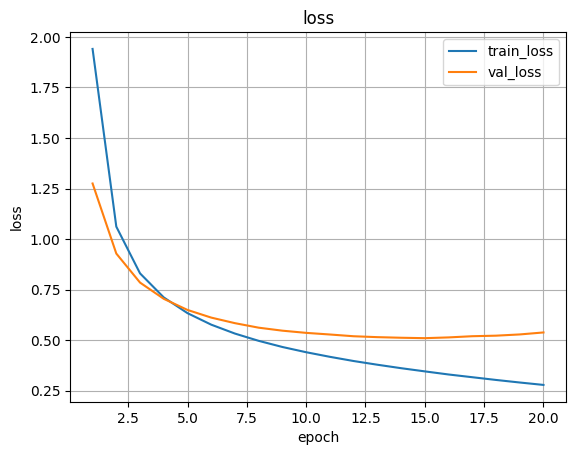

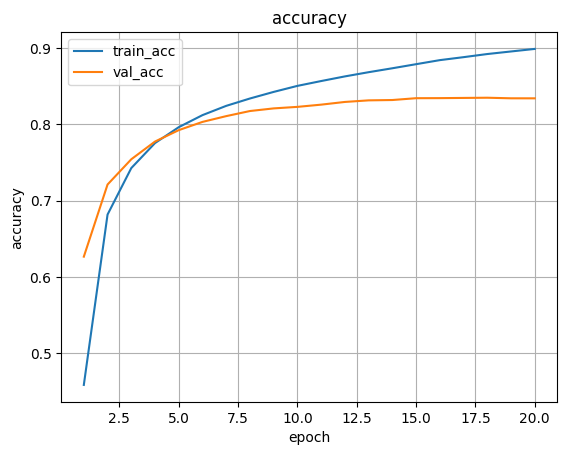

In [ ]:
print("=== E1: Base model (no dropout, no batchnorm) ===")
first_model = MLP(hidden_layers=(1024,512,256,128,64)).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(first_model.parameters(),lr=1e-4)

history_first_model = fit(
    first_model, train_loader, val_loader, optimizer, criterion, device,epochs=20
)

plot_history(history_first_model, title="E1")

100%|██████████| 50/50 [14:24<00:00, 17.29s/it]

epoch 49/50 | train loss=0.3476, acc=0.8768 | val loss=0.4564, acc=0.8615


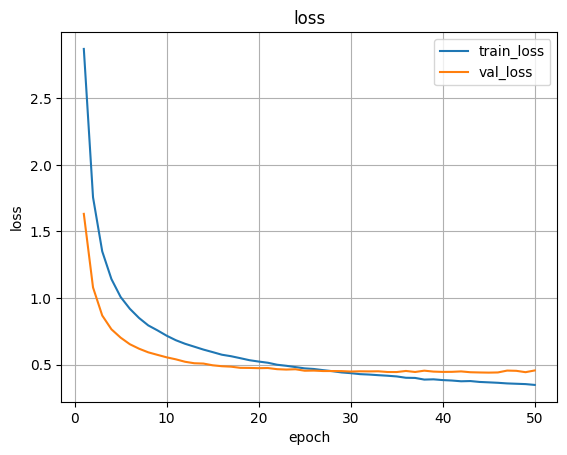

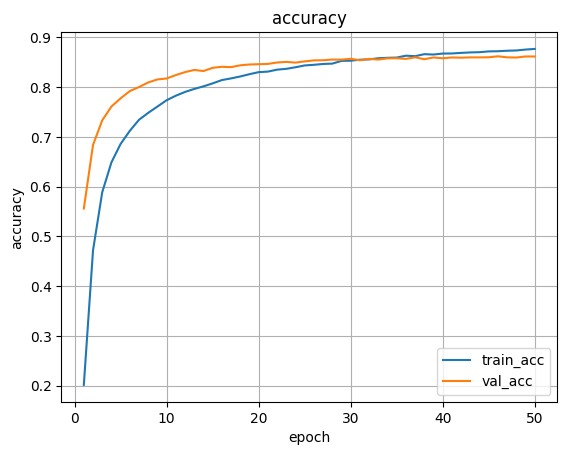

In [ ]:
print("=== E2: With Dropout (p=0.3) ===")
second_model = MLP(hidden_layers=(1024,512,256,128,64), p_dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(second_model.parameters(),lr=1e-4)

history_second_model = fit(
    second_model, train_loader, val_loader, optimizer, criterion, device,epochs=50
)

plot_history(history_second_model)

100%|██████████| 30/30 [07:41<00:00, 15.37s/it]

epoch 29/30 | train loss=0.0436, acc=0.9854 | val loss=0.8313, acc=0.8294


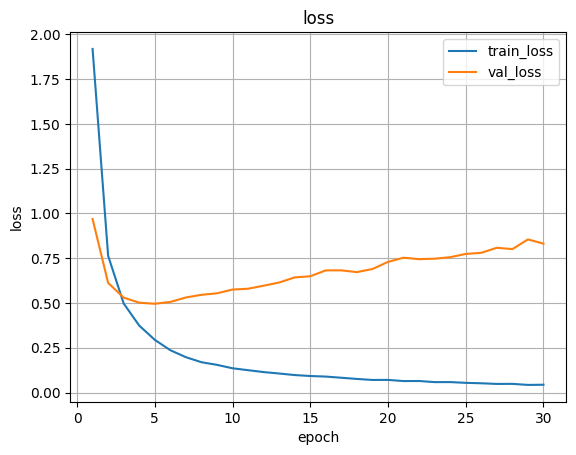

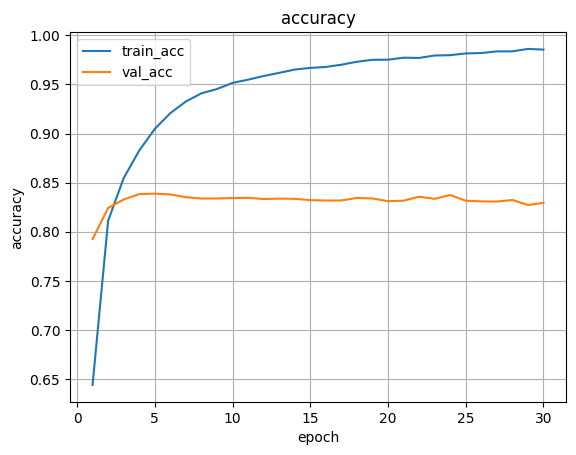

In [ ]:
print("=== E3: With BatchNorm ===")
third_model = MLP(hidden_layers=(1024,512,256,128,64),batchNorm=True).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(third_model.parameters(),lr=1e-4)

history_third_model = fit(
    third_model, train_loader, val_loader, optimizer, criterion, device,epochs=30
)

plot_history(history_third_model)

 62%|██████▏   | 37/60 [10:33<06:33, 17.13s/it]

epoch 37/60 | train loss=0.3966, acc=0.8643 | val loss=0.4619, acc=0.8560
EarlyStopping: остановка на эпохе 37. Лучший val_acc=0.4553


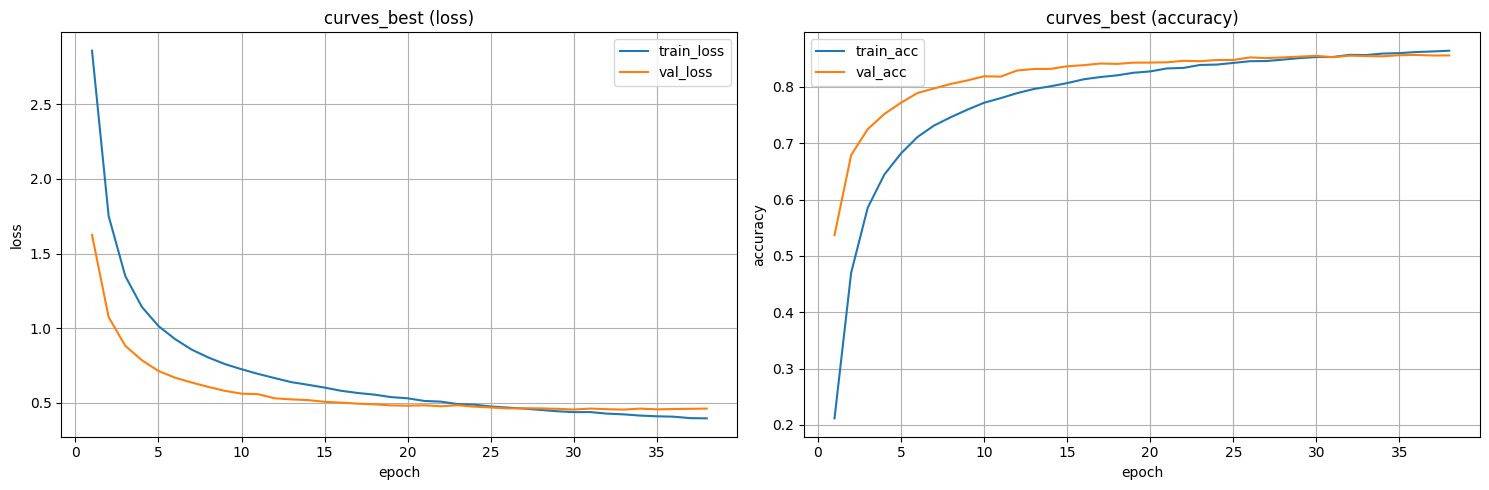

In [18]:
print("=== E4: Best Model ===")
fourth_model = MLP(hidden_layers=(1024,512,256,128,64), p_dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fourth_model.parameters(),lr=1e-4)

history_fourth_model = fit(
    fourth_model, train_loader, val_loader, optimizer, criterion, device,epochs=60,early_stopping=EarlyStopping(patience=5,min_delta=0)
)

plot_history(history_fourth_model, title = "curves_best", save=True)

In [24]:
best_model = fourth_model
torch.save(best_model.state_dict(), "artifacts/best_model.pt")

In [3]:
import json

best_config = {
    'experiment_id': 'E4',
    'dataset': 'EMNIST',  
    'seed': 42,
    'model': {
        'hidden_sizes': [1024, 512, 256, 128, 64],  
        'activation': 'relu',
        'dropout': 0.3,
        'batchnorm': False 
    },
    'optimizer': {
        'name': 'Adam',
        'lr': 0.0001,
        'weight_decay': 0
    },
    'early_stopping_patience': 5,
    'best_val_accuracy': 0.8596,
    'epochs_trained': 44
}

with open(r'artifacts/best_config.json', 'w') as f:
    json.dump(best_config, f, indent=4)

In [25]:
best_model.load_state_dict(torch.load("artifacts/best_model.pt"))

test_loss, test_acc = evaluate_model(best_model, test_loader, criterion, device)

print(f"\n=== Финальная оценка на тестовом наборе ===")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc:.4f}")


=== Финальная оценка на тестовом наборе ===
Test loss: 0.4741
Test accuracy: 0.8539


# 

# Часть Б

 83%|████████▎ | 5/6 [01:47<00:21, 21.47s/it]

epoch 05/6 | train loss=3.8706, acc=0.0209 | val loss=3.8746, acc=0.0210
EarlyStopping: остановка на эпохе 5. Лучший val_acc=3.8743


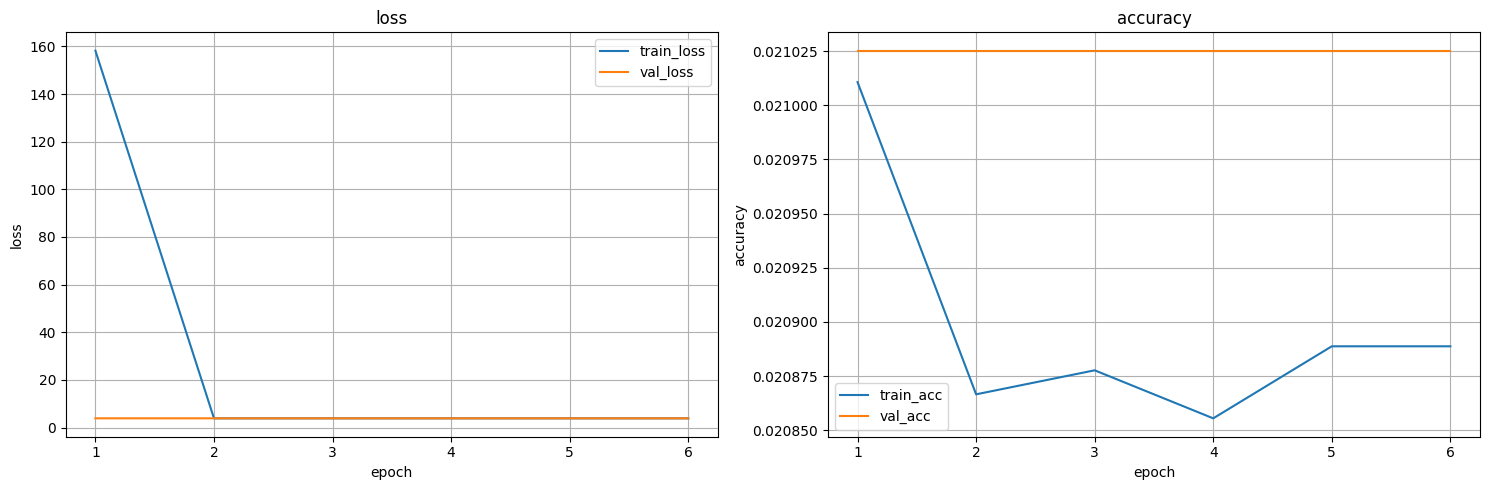

In [ ]:
print("=== O1: Adam, LR too high (1e-1) ===")
fifth_model = MLP(hidden_layers=(1024,512,256,128,64), p_dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(fifth_model.parameters(),lr=1e-1)


history_fifth_model = fit(
    fifth_model, train_loader, val_loader, optimizer, criterion, device,epochs=6,early_stopping=EarlyStopping(patience=5,min_delta=0)
)

plot_history(history_fifth_model)

100%|██████████| 6/6 [01:43<00:00, 17.30s/it]

epoch 05/6 | train loss=2.6518, acc=0.2521 | val loss=2.1493, acc=0.4549


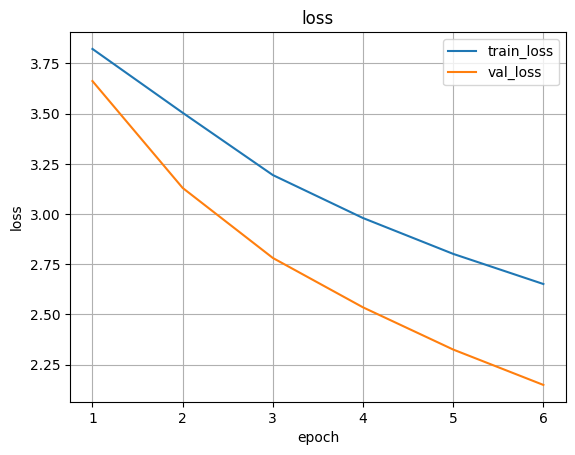

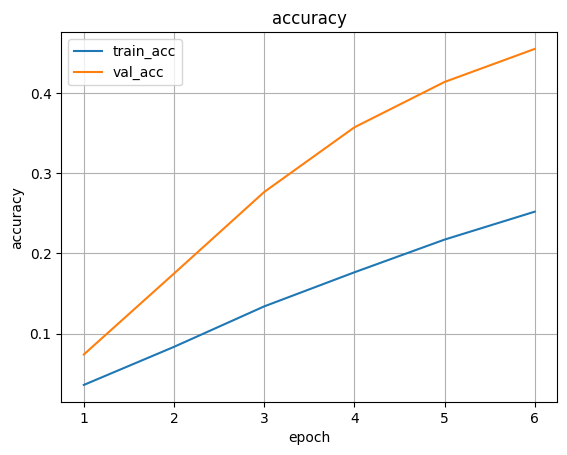

In [ ]:
print("=== O2: Adam, LR too low (1e-5) ===")
sixth_model = MLP(hidden_layers=(1024,512,256,128,64), p_dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(sixth_model.parameters(),lr=1e-5)


history_sixth_model = fit(
    sixth_model, train_loader, val_loader, optimizer, criterion, device,epochs=6,early_stopping=EarlyStopping(patience=5,min_delta=0)
)

plot_history(history_sixth_model)

100%|██████████| 15/15 [03:57<00:00, 15.83s/it]

epoch 14/15 | train loss=1.0902, acc=0.6541 | val loss=0.7972, acc=0.7490


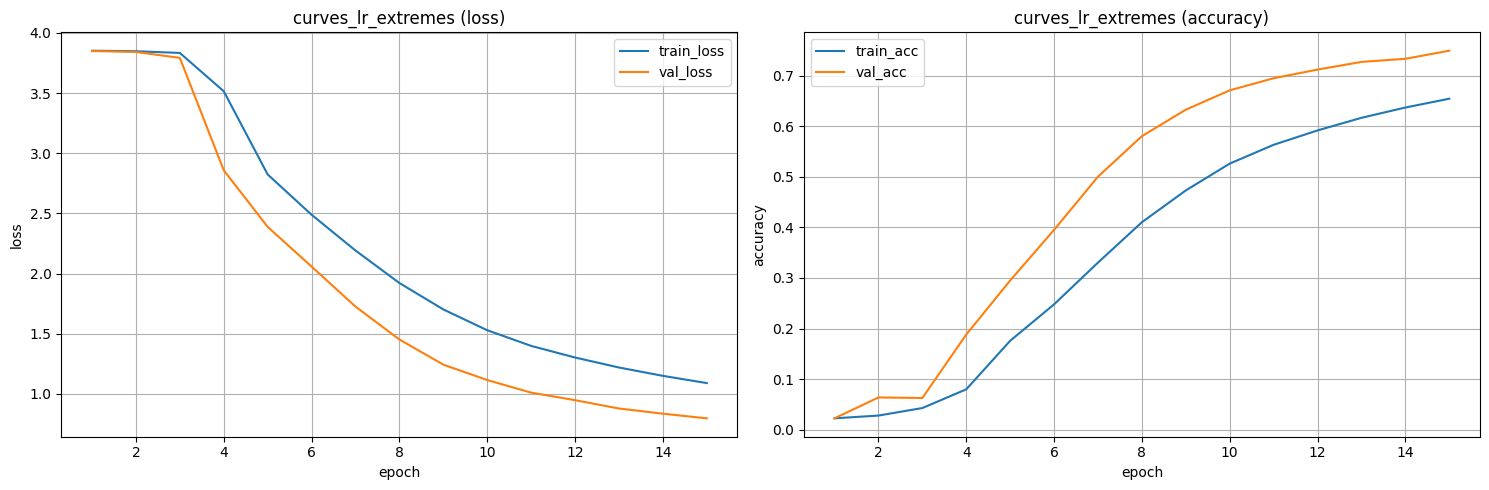

In [22]:
print("=== O3: SGD with momentum=0.9, weight_decay=1e-4 ===")
seventh_model = MLP(hidden_layers=(1024,512,256,128,64), p_dropout=0.3).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(seventh_model.parameters(),lr=1e-3,momentum=0.9, weight_decay=1e-4)


history_seventh_model = fit(
    seventh_model, train_loader, val_loader, optimizer, criterion, device,epochs=15,early_stopping=EarlyStopping(patience=5,min_delta=0)
)

plot_history(history_seventh_model, title="curves_lr_extremes",save=True)

In [8]:
data = [
    ["E1", "EMNIST", 42, "1024,512,256,128,64 / relu / dropout=0 / batchnorm=False", "Adam", 0.001, "", 0, 20, 0.8343, 0.5380],
    ["E2", "EMNIST", 42, "1024,512,256,128,64 / relu / dropout=0.3 / batchnorm=False", "Adam", 0.001, "", 0, 50, 0.8615, 0.4564],
    ["E3", "EMNIST", 42, "1024,512,256,128,64 / relu / dropout=0 / batchnorm=True", "Adam", 0.001, "", 0, 30, 0.8294, 0.8313],
    ["E4", "EMNIST", 42, "1024,512,256,128,64 / relu / dropout=0.3 / batchnorm=False", "Adam", 0.001, "", 0, 44, 0.8596, 0.4516],
    ["O1", "EMNIST", 42, "1024,512,256,128,64 / relu / dropout=0.3 / batchnorm=False", "Adam", 0.1, "", 0, 6, 0.0210, 3.8746],
    ["O2", "EMNIST", 42, "1024,512,256,128,64 / relu / dropout=0.3 / batchnorm=False", "Adam", 0.00001, "", 0, 6, 0.4549, 2.1493],
    ["O3", "EMNIST", 42, "1024,512,256,128,64 / relu / dropout=0.3 / batchnorm=False", "SGD", 0.001, 0.9, 0.0001, 15, 0.7520, 0.7824]
]

columns = [
    "experiment_id", "dataset", "seed", "model_summary", "optimizer",
    "lr", "momentum", "weight_decay", "epochs_trained",
    "best_val_accuracy", "best_val_loss"
]

df = pd.DataFrame(data, columns=columns)

df.to_csv("artifacts/runs.csv", index=False)